In [ ]:
# ── CELL 0: Upload your dataset to Colab ──
from google.colab import files
uploaded = files.upload()
# → A file picker will appear → select student_performance_enhanced.xlsx

Saving xypher3.xlsx to xypher3 (1).xlsx


STEP 1: LOADING DATASETS
✅ Main dataset loaded: 14003 rows × 25 columns
⚠️  Kaggle CSV not found — running with main dataset only.

── Main Dataset Columns ──
['RollNo', 'StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade', 'Sem1_Marks', 'Sem2_Marks', 'Sem3_Marks', 'Sem4_Marks', 'Total_Marks', 'Average', 'Grade', 'Pass_Fail']

STEP 2: EXPLORATORY DATA ANALYSIS

── Shape ──
(14003, 25)

── First 5 rows ──
    RollNo  StudyHours  Attendance  Resources  Extracurricular  Motivation  \
0  STU1000          19          64          1                0           0   
1  STU1001          19          64          1                0           0   
2  STU1002          19          64          1                0           0   
3  STU1003          19          64          1                1           0   
4  STU1004          19     

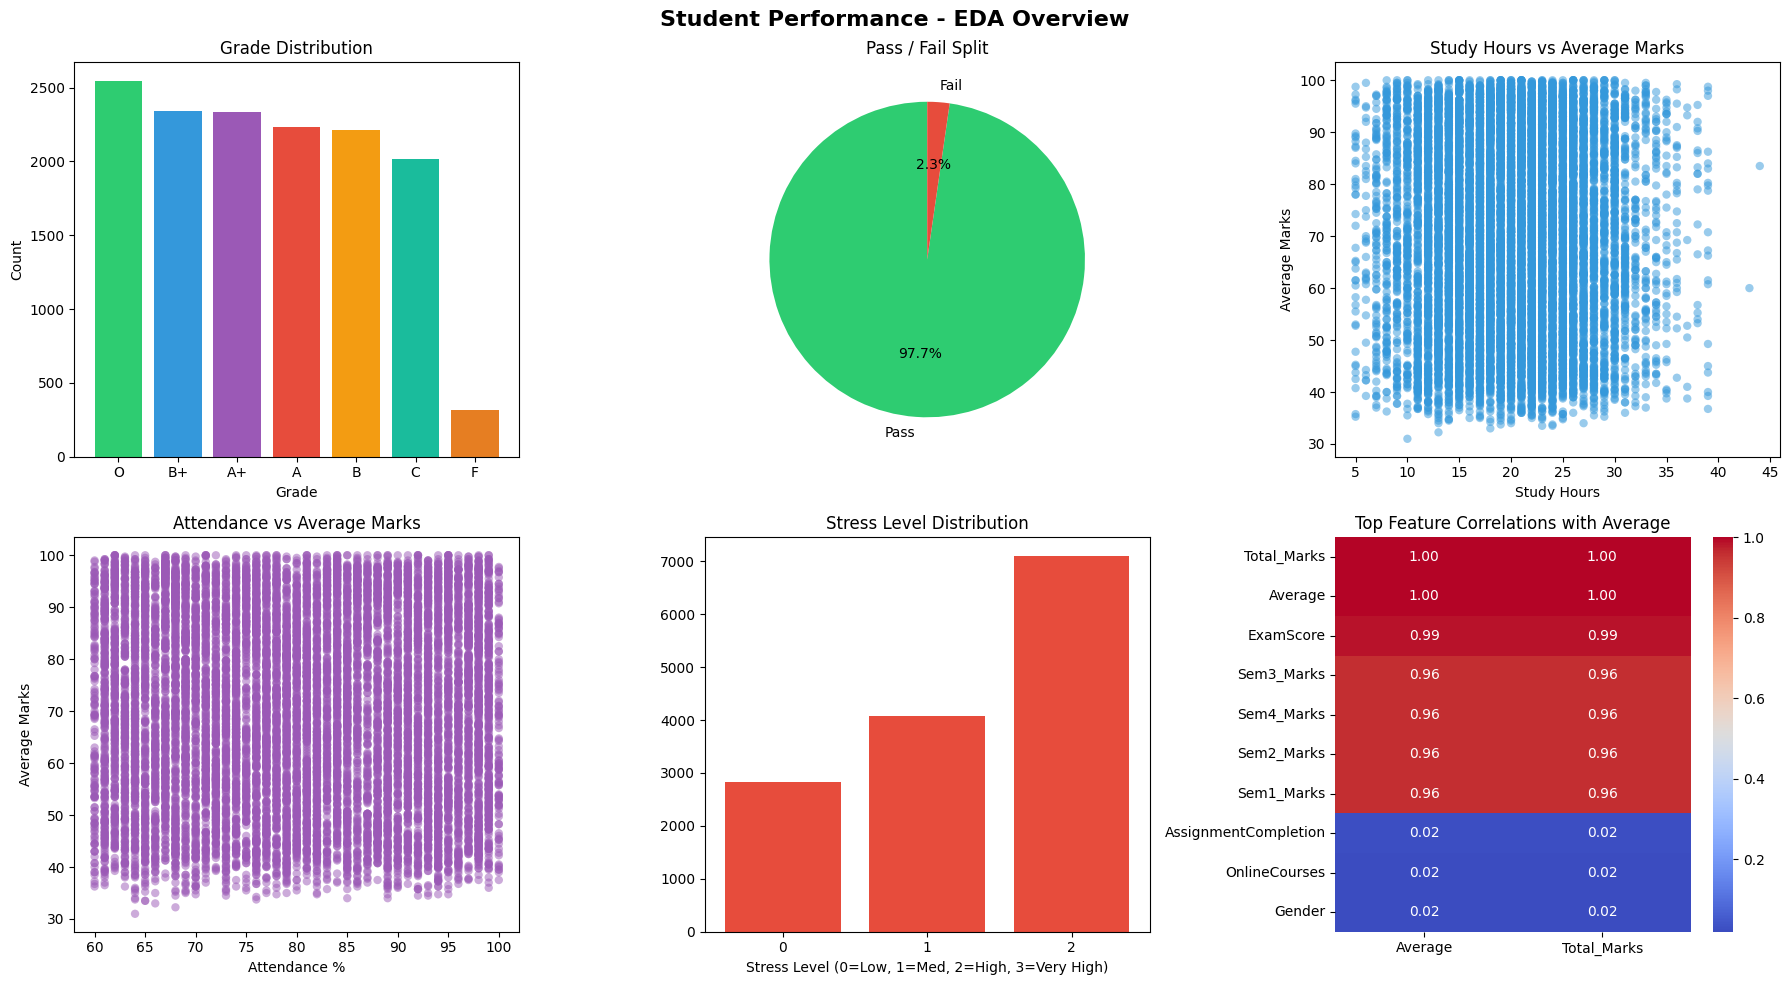

✅ EDA plots saved as eda_overview.png

STEP 3: DATA PREPROCESSING
   Encoded 'Gender': {'0': np.int64(0), '1': np.int64(1)}
   Encoded 'Pass_Fail': {'Fail': np.int64(0), 'Pass': np.int64(1)}
   Encoded 'Grade': {'A': np.int64(0), 'A+': np.int64(1), 'B': np.int64(2), 'B+': np.int64(3), 'C': np.int64(4), 'F': np.int64(5), 'O': np.int64(6)}
   Encoded 'FinalGrade': {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3': np.int64(3)}

✅ After cleaning — missing values: 0

── New Features Added ──
   Mark_Consistency, Improvement_Trend, Engagement_Score, Risk_Score
       Mark_Consistency  Improvement_Trend  Engagement_Score    Risk_Score
count      14003.000000       14003.000000      14003.000000  14003.000000
mean           5.522532          -0.107263         32.154088      1.893951
std            1.995522           8.320905          4.097947      1.599696
min            0.000000         -20.000000         20.000000      0.000000
25%            4.112988          -6.000000         29.

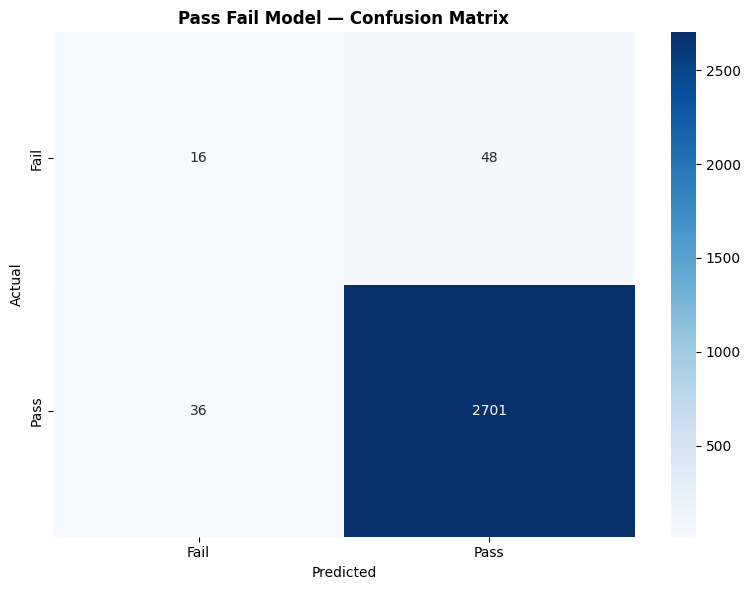


STEP 6: MODEL 2 — GRADE PREDICTION (Multi-class)
   [Grade Model] Epoch  10/100 | Train Loss: 0.7428 | Train Acc: 0.6767 | Val Loss: 0.6360 | Val Acc: 0.7305
   [Grade Model] Epoch  20/100 | Train Loss: 0.7005 | Train Acc: 0.7045 | Val Loss: 0.5418 | Val Acc: 0.7651
   [Grade Model] Epoch  30/100 | Train Loss: 0.6418 | Train Acc: 0.7223 | Val Loss: 0.6019 | Val Acc: 0.7297
   [Grade Model] Epoch  40/100 | Train Loss: 0.6205 | Train Acc: 0.7344 | Val Loss: 0.5953 | Val Acc: 0.7483
   [Grade Model] Epoch  50/100 | Train Loss: 0.6121 | Train Acc: 0.7500 | Val Loss: 0.5844 | Val Acc: 0.7426
   [Grade Model] Epoch  60/100 | Train Loss: 0.6192 | Train Acc: 0.7455 | Val Loss: 0.5704 | Val Acc: 0.7408
   [Grade Model] Epoch  70/100 | Train Loss: 0.5718 | Train Acc: 0.7503 | Val Loss: 0.7149 | Val Acc: 0.6887
   [Grade Model] Epoch  80/100 | Train Loss: 0.5739 | Train Acc: 0.7556 | Val Loss: 0.6272 | Val Acc: 0.7240
   [Grade Model] Epoch  90/100 | Train Loss: 0.5953 | Train Acc: 0.7519 | Val 

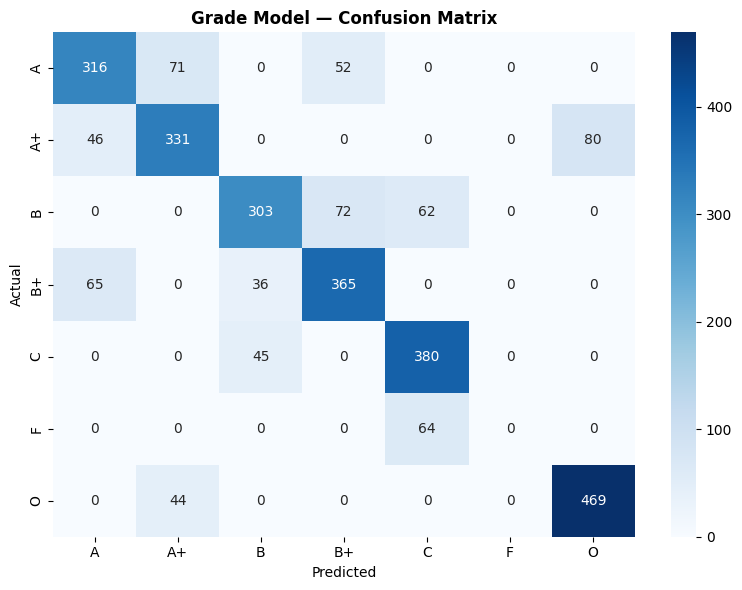


STEP 7: TRAINING CURVES


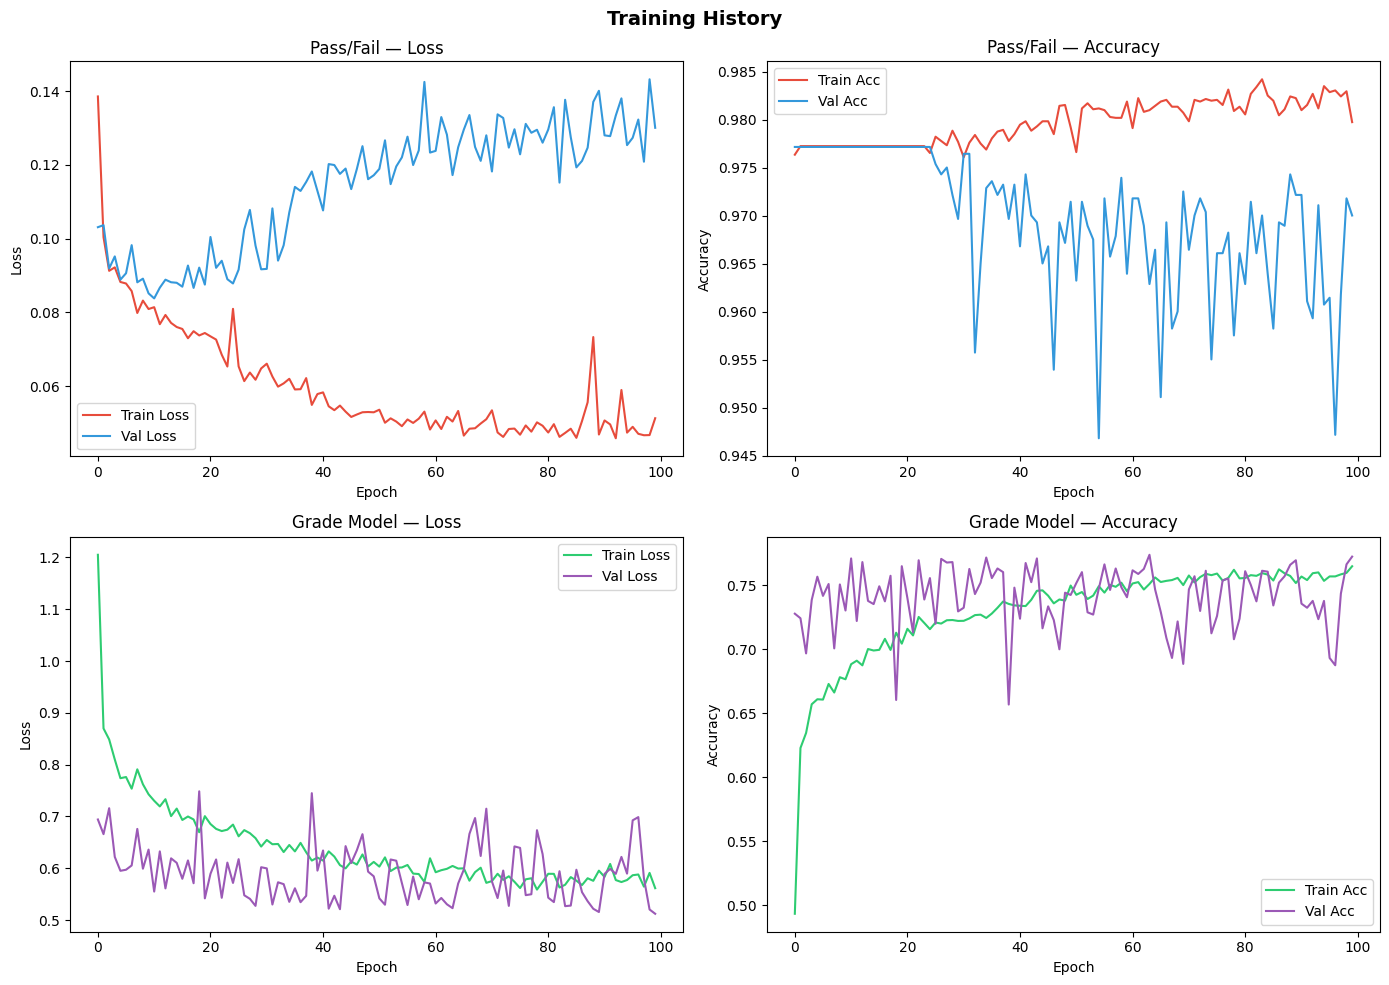

✅ Training curves saved.

STEP 8: SKLEARN BASELINE MODELS
   Random Forest — Acc: 0.9654 | F1: 0.9705
   Decision Tree  — Acc: 0.9529 | F1: 0.9636

── Model Comparison ──
                 Model  Accuracy  F1 Score
PyTorch NN (Pass/Fail)  0.970011  0.968492
    PyTorch NN (Grade)  0.772581  0.761950
         Random Forest  0.965370  0.970522
         Decision Tree  0.952874  0.963566


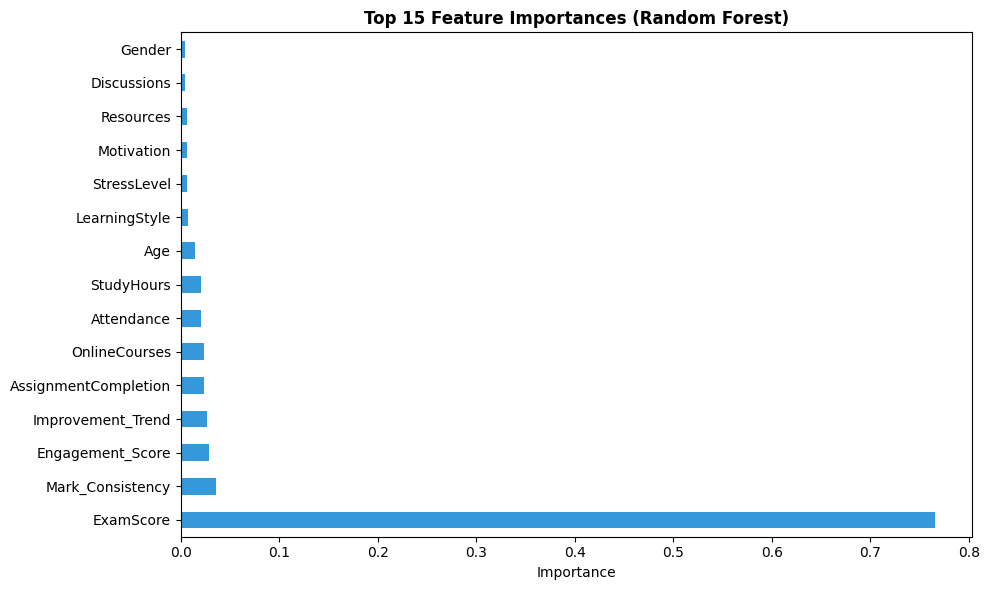

✅ Feature importance saved.

STEP 9: RISK CLASSIFICATION SYSTEM
── Risk Level Distribution ──
Risk_Level
🟢 LOW RISK       8259
🟡 MEDIUM RISK    4720
🔴 HIGH RISK      1024
Name: count, dtype: int64

STEP 10: RECOMMENDATIONS ENGINE

── Sample Student: STU1010 ──
   Risk: 🟢 LOW RISK (score=3)
   Risk Factors: ['Low attendance (<75%)']
   Recommendations:
      📅 ATTENDANCE: Aim for at least 75% attendance. Missing classes is a top risk factor.
      💬 DISCUSSIONS: Participate in class discussions — it improves retention.

STEP 12: SAVING MODELS & RESULTS
✅ PyTorch models saved: model_pass_fail.pth, model_grade.pth
✅ Scaler + encoders saved.
✅ Student risk report saved: student_risk_risk_report.csv

STEP 13: INFERENCE FUNCTION

── Test Inference on At-Risk Student ──
   Prediction  : Pass | Grade: C
   Pass Prob   : 0.9541
   Risk Level  : 🔴 HIGH RISK (score=9)
   Risk Factors: ['Low attendance (<75%)', 'High stress level', 'Low study hours (<15)', 'Assignments not completed', 'Low motivat

In [ ]:
# ============================================================
# STUDENT PERFORMANCE PREDICTION & MONITORING SYSTEM
# Team: TESSERACT-X | Problem: P-02
# Full ML Pipeline: EDA → Preprocessing → PyTorch Model
#                   → Risk Classification → Recommendations
# ============================================================

# ─────────────────────────────────────────
# STEP 0: INSTALL & IMPORTS
# ─────────────────────────────────────────
# Run this in Colab first if needed:
# !pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn openpyxl kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import os

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ─────────────────────────────────────────
# STEP 1: LOAD DATASETS
# ─────────────────────────────────────────

print("=" * 60)
print("STEP 1: LOADING DATASETS")
print("=" * 60)

# ── 1A. Load the given hackathon dataset ──
# Upload your file to Colab or change the path
df_main = pd.read_excel("xypher3 (1).xlsx", sheet_name="Student Performance")
print(f"✅ Main dataset loaded: {df_main.shape[0]} rows × {df_main.shape[1]} columns")

# ── 1B. Load Kaggle 'Students Performance in Exams' ──
# Download from: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
# OR use kagglehub in Colab:
#   import kagglehub
#   path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
#   df_kaggle_raw = pd.read_csv(f"{path}/StudentsPerformance.csv")

# For now, we simulate it (replace with real load when running):
try:
    df_kaggle_raw = pd.read_csv("StudentsPerformance.csv")
    print(f"✅ Kaggle dataset loaded: {df_kaggle_raw.shape}")
    USE_KAGGLE = True
except:
    print("⚠️  Kaggle CSV not found — running with main dataset only.")
    USE_KAGGLE = False

print("\n── Main Dataset Columns ──")
print(list(df_main.columns))

# ─────────────────────────────────────────
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Basic info
print("\n── Shape ──")
print(df_main.shape)

print("\n── First 5 rows ──")
print(df_main.head())

print("\n── Data Types ──")
print(df_main.dtypes)

print("\n── Missing Values ──")
print(df_main.isnull().sum())

print("\n── Descriptive Statistics ──")
print(df_main.describe())

# ── Grade Distribution ──
print("\n── Grade Distribution ──")
print(df_main['Grade'].value_counts())

print("\n── Pass/Fail Distribution ──")
print(df_main['Pass_Fail'].value_counts())

# ── EDA PLOTS ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Student Performance - EDA Overview', fontsize=16, fontweight='bold')

# 1. Grade distribution
grade_counts = df_main['Grade'].value_counts()
axes[0, 0].bar(grade_counts.index, grade_counts.values,
               color=['#2ecc71','#3498db','#9b59b6','#e74c3c','#f39c12','#1abc9c','#e67e22'])
axes[0, 0].set_title('Grade Distribution')
axes[0, 0].set_xlabel('Grade')
axes[0, 0].set_ylabel('Count')

# 2. Pass/Fail pie
pf_counts = df_main['Pass_Fail'].value_counts()
axes[0, 1].pie(pf_counts.values, labels=pf_counts.index, autopct='%1.1f%%',
               colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0, 1].set_title('Pass / Fail Split')

# 3. Study Hours vs Average
axes[0, 2].scatter(df_main['StudyHours'], df_main['Average'],
                   alpha=0.5, c='#3498db', edgecolors='none')
axes[0, 2].set_title('Study Hours vs Average Marks')
axes[0, 2].set_xlabel('Study Hours')
axes[0, 2].set_ylabel('Average Marks')

# 4. Attendance vs Average
axes[1, 0].scatter(df_main['Attendance'], df_main['Average'],
                   alpha=0.5, c='#9b59b6', edgecolors='none')
axes[1, 0].set_title('Attendance vs Average Marks')
axes[1, 0].set_xlabel('Attendance %')
axes[1, 0].set_ylabel('Average Marks')

# 5. Stress Level distribution
stress_counts = df_main['StressLevel'].value_counts().sort_index()
axes[1, 1].bar(stress_counts.index.astype(str), stress_counts.values, color='#e74c3c')
axes[1, 1].set_title('Stress Level Distribution')
axes[1, 1].set_xlabel('Stress Level (0=Low, 1=Med, 2=High, 3=Very High)')

# 6. Correlation heatmap (numeric only)
numeric_cols = df_main.select_dtypes(include=[np.number]).columns.tolist()
corr = df_main[numeric_cols].corr()
sns.heatmap(corr[['Average','Total_Marks']].sort_values('Average', ascending=False).head(10),
            annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2])
axes[1, 2].set_title('Top Feature Correlations with Average')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved as eda_overview.png")

# ─────────────────────────────────────────
# STEP 3: DATA PREPROCESSING
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 3: DATA PREPROCESSING")
print("=" * 60)

df = df_main.copy()

# ── 3A. Drop identifier column ──
df.drop(columns=['RollNo'], inplace=True)

# ── 3B. Encode categorical columns ──
cat_cols = ['Gender', 'Pass_Fail', 'Grade', 'FinalGrade']
le_dict = {}

for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
        print(f"   Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── 3C. Handle missing values ──
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in [np.float64, np.int64]:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

print(f"\n✅ After cleaning — missing values: {df.isnull().sum().sum()}")

# ── 3D. Feature Engineering ──
# Consistency Score: how consistent are semester marks
df['Mark_Consistency'] = df[['Sem1_Marks','Sem2_Marks','Sem3_Marks','Sem4_Marks']].std(axis=1)

# Improvement Trend: Sem4 - Sem1
df['Improvement_Trend'] = df['Sem4_Marks'] - df['Sem1_Marks']

# Engagement Score: combines study hours, attendance, online courses, discussions
df['Engagement_Score'] = (
    df['StudyHours'] * 0.3 +
    df['Attendance'] * 0.3 +
    df['OnlineCourses'] * 0.2 +
    df['Discussions'] * 0.2
)

# Risk Score (rule-based, used later for recommendations)
df['Risk_Score'] = 0
df.loc[df['Attendance'] < 75, 'Risk_Score'] += 2
df.loc[df['Average'] < 50, 'Risk_Score'] += 3
df.loc[df['StressLevel'] >= 2, 'Risk_Score'] += 1
df.loc[df['AssignmentCompletion'] == 0, 'Risk_Score'] += 1
df.loc[df['StudyHours'] < 15, 'Risk_Score'] += 1

print("\n── New Features Added ──")
print("   Mark_Consistency, Improvement_Trend, Engagement_Score, Risk_Score")
print(df[['Mark_Consistency','Improvement_Trend','Engagement_Score','Risk_Score']].describe())

# ── 3E. Define X (features) and y (targets) ──

# We'll train 2 models:
# Model 1: Predict Pass_Fail (Binary Classification)
# Model 2: Predict Grade (Multi-class Classification)

# Remove target leakage columns from features
EXCLUDE_COLS = ['Pass_Fail', 'Grade', 'FinalGrade', 'Total_Marks',
                'Average', 'Sem1_Marks','Sem2_Marks','Sem3_Marks','Sem4_Marks',
                'Risk_Score']

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X = df[feature_cols].values
y_binary = df['Pass_Fail'].values          # 0=Fail, 1=Pass
y_grade  = df['Grade'].values              # multi-class

print(f"\n✅ Features used ({len(feature_cols)}): {feature_cols}")
print(f"   y_binary classes: {np.unique(y_binary)}")
print(f"   y_grade classes: {np.unique(y_grade)} → {list(le_dict['Grade'].classes_)}")

# ── 3F. Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 3G. Train / Test split ──
X_train, X_test, y_train_bin, y_test_bin, y_train_grade, y_test_grade = train_test_split(
    X_scaled, y_binary, y_grade, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\n✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# ─────────────────────────────────────────
# STEP 4: PYTORCH MODEL DEFINITION
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 4: PYTORCH NEURAL NETWORK MODELS")
print("=" * 60)

# ── 4A. Dataset class ──
class StudentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ── 4B. Neural Network Architecture ──
class StudentNet(nn.Module):
    """
    Deep Neural Network for student performance prediction.
    Architecture: Input → 256 → 128 → 64 → 32 → Output
    With Batch Norm + Dropout for regularization
    """
    def __init__(self, input_dim, num_classes, dropout_rate=0.3):
        super(StudentNet, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 4
            nn.Linear(64, 32),
            nn.ReLU(),

            # Output
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# ── 4C. Training function ──
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, epochs=100, model_name="Model"):
    """
    Full training loop with validation tracking.
    Returns: trained model + history dict
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        # ── Training phase ──
        model.train()
        total_loss, correct, total = 0, 0, 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        # ── Validation phase ──
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)

        val_loss /= len(val_loader)
        val_acc   = val_correct / val_total

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

        if (epoch + 1) % 10 == 0:
            print(f"   [{model_name}] Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Restore best model
    model.load_state_dict(best_model_state)
    print(f"\n✅ {model_name} — Best Val Acc: {best_val_acc:.4f}")
    return model, history

# ── 4D. Evaluation function ──
def evaluate_model(model, X_test_tensor, y_test, label_names=None, model_name="Model"):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs, 1)
        probs = torch.softmax(outputs, dim=1).numpy()

    y_pred = predicted.numpy()
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')

    print(f"\n── {model_name} Evaluation ──")
    print(f"   Accuracy : {acc:.4f}")
    print(f"   F1 Score : {f1:.4f}")
    print(f"\n   Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ","_")}.png', dpi=150)
    plt.show()

    return acc, f1, y_pred, probs

# ─────────────────────────────────────────
# STEP 5: TRAIN MODEL 1 — PASS/FAIL (BINARY)
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 5: MODEL 1 — PASS/FAIL PREDICTION (Binary)")
print("=" * 60)

# DataLoaders
train_ds_bin = StudentDataset(X_train, y_train_bin)
test_ds_bin  = StudentDataset(X_test,  y_test_bin)
train_loader_bin = DataLoader(train_ds_bin, batch_size=32, shuffle=True)
test_loader_bin  = DataLoader(test_ds_bin,  batch_size=32, shuffle=False)

input_dim  = X_train.shape[1]
model_bin  = StudentNet(input_dim=input_dim, num_classes=2, dropout_rate=0.3)

# Loss: weighted to handle class imbalance
class_weights = torch.tensor([1.5, 1.0], dtype=torch.float32)  # higher weight for Fail
criterion_bin  = nn.CrossEntropyLoss(weight=class_weights)
optimizer_bin  = optim.Adam(model_bin.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_bin  = optim.lr_scheduler.ReduceLROnPlateau(optimizer_bin, patience=10, factor=0.5)

model_bin, history_bin = train_model(
    model_bin, train_loader_bin, test_loader_bin,
    criterion_bin, optimizer_bin, scheduler_bin,
    epochs=100, model_name="Pass/Fail Model"
)

# Evaluate
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
acc_bin, f1_bin, y_pred_bin, probs_bin = evaluate_model(
    model_bin, X_test_tensor, y_test_bin,
    label_names=['Fail', 'Pass'], model_name="Pass Fail Model"
)

# ─────────────────────────────────────────
# STEP 6: TRAIN MODEL 2 — GRADE (MULTICLASS)
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 6: MODEL 2 — GRADE PREDICTION (Multi-class)")
print("=" * 60)

num_grade_classes = len(np.unique(y_grade))
grade_labels      = list(le_dict['Grade'].classes_)

train_ds_grade = StudentDataset(X_train, y_train_grade)
test_ds_grade  = StudentDataset(X_test,  y_test_grade)
train_loader_grade = DataLoader(train_ds_grade, batch_size=32, shuffle=True)
test_loader_grade  = DataLoader(test_ds_grade,  batch_size=32, shuffle=False)

model_grade     = StudentNet(input_dim=input_dim, num_classes=num_grade_classes, dropout_rate=0.3)
criterion_grade = nn.CrossEntropyLoss()
optimizer_grade = optim.Adam(model_grade.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_grade = optim.lr_scheduler.ReduceLROnPlateau(optimizer_grade, patience=10, factor=0.5)

model_grade, history_grade = train_model(
    model_grade, train_loader_grade, test_loader_grade,
    criterion_grade, optimizer_grade, scheduler_grade,
    epochs=100, model_name="Grade Model"
)

acc_grade, f1_grade, y_pred_grade, probs_grade = evaluate_model(
    model_grade, X_test_tensor, y_test_grade,
    label_names=grade_labels, model_name="Grade Model"
)

# ─────────────────────────────────────────
# STEP 7: TRAINING CURVES
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 7: TRAINING CURVES")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Pass/Fail loss
axes[0,0].plot(history_bin['train_loss'], label='Train Loss', color='#e74c3c')
axes[0,0].plot(history_bin['val_loss'],   label='Val Loss',   color='#3498db')
axes[0,0].set_title('Pass/Fail — Loss')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend()

# Pass/Fail accuracy
axes[0,1].plot(history_bin['train_acc'], label='Train Acc', color='#e74c3c')
axes[0,1].plot(history_bin['val_acc'],   label='Val Acc',   color='#3498db')
axes[0,1].set_title('Pass/Fail — Accuracy')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()

# Grade loss
axes[1,0].plot(history_grade['train_loss'], label='Train Loss', color='#2ecc71')
axes[1,0].plot(history_grade['val_loss'],   label='Val Loss',   color='#9b59b6')
axes[1,0].set_title('Grade Model — Loss')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Loss')
axes[1,0].legend()

# Grade accuracy
axes[1,1].plot(history_grade['train_acc'], label='Train Acc', color='#2ecc71')
axes[1,1].plot(history_grade['val_acc'],   label='Val Acc',   color='#9b59b6')
axes[1,1].set_title('Grade Model — Accuracy')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved.")

# ─────────────────────────────────────────
# STEP 8: SKLEARN BASELINES (FOR COMPARISON)
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 8: SKLEARN BASELINE MODELS")
print("=" * 60)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train_bin)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test_bin, rf_pred)
rf_f1   = f1_score(y_test_bin, rf_pred, average='weighted')
print(f"   Random Forest — Acc: {rf_acc:.4f} | F1: {rf_f1:.4f}")

# Decision Tree
dt = DecisionTreeClassifier(max_depth=8, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train_bin)
dt_pred = dt.predict(X_test)
dt_acc  = accuracy_score(y_test_bin, dt_pred)
dt_f1   = f1_score(y_test_bin, dt_pred, average='weighted')
print(f"   Decision Tree  — Acc: {dt_acc:.4f} | F1: {dt_f1:.4f}")

# Compare all models
print("\n── Model Comparison ──")
model_results = pd.DataFrame({
    'Model':    ['PyTorch NN (Pass/Fail)', 'PyTorch NN (Grade)', 'Random Forest', 'Decision Tree'],
    'Accuracy': [acc_bin, acc_grade, rf_acc, dt_acc],
    'F1 Score': [f1_bin,  f1_grade,  rf_f1,  dt_f1]
})
print(model_results.to_string(index=False))

# Feature importance from RF
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Top 15 Feature Importances (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved.")

# ─────────────────────────────────────────
# STEP 9: RISK CLASSIFICATION SYSTEM
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 9: RISK CLASSIFICATION SYSTEM")
print("=" * 60)

def classify_risk(student_row):
    """
    Classify student into High / Medium / Low risk.
    Returns: risk_level (str) + risk_factors (list)
    """
    score = 0
    factors = []

    if student_row.get('Attendance', 100) < 75:
        score += 3
        factors.append("Low attendance (<75%)")

    if student_row.get('Average', 100) < 40:
        score += 4
        factors.append("Very low average marks (<40)")
    elif student_row.get('Average', 100) < 50:
        score += 2
        factors.append("Below average marks (<50)")

    if student_row.get('StressLevel', 0) >= 2:
        score += 2
        factors.append("High stress level")

    if student_row.get('StudyHours', 10) < 10:
        score += 2
        factors.append("Very few study hours (<10)")
    elif student_row.get('StudyHours', 10) < 15:
        score += 1
        factors.append("Low study hours (<15)")

    if student_row.get('AssignmentCompletion', 1) == 0:
        score += 2
        factors.append("Assignments not completed")

    if student_row.get('Motivation', 1) == 0:
        score += 1
        factors.append("Low motivation")

    if student_row.get('Improvement_Trend', 0) < -10:
        score += 2
        factors.append("Declining performance trend")

    # Classify
    if score >= 7:
        risk = "🔴 HIGH RISK"
    elif score >= 4:
        risk = "🟡 MEDIUM RISK"
    else:
        risk = "🟢 LOW RISK"

    return risk, factors, score

# ── Apply to full dataset ──
df_orig = df_main.copy()

# Add engineered features
df_orig['Mark_Consistency'] = df_orig[['Sem1_Marks','Sem2_Marks','Sem3_Marks','Sem4_Marks']].std(axis=1)
df_orig['Improvement_Trend'] = df_orig['Sem4_Marks'] - df_orig['Sem1_Marks']

risk_levels, risk_scores_list = [], []
for _, row in df_orig.iterrows():
    rl, _, rs = classify_risk(row.to_dict())
    risk_levels.append(rl)
    risk_scores_list.append(rs)

df_orig['Risk_Level']      = risk_levels
df_orig['Risk_Score_Calc'] = risk_scores_list

print("── Risk Level Distribution ──")
print(df_orig['Risk_Level'].value_counts())

# ─────────────────────────────────────────
# STEP 10: RECOMMENDATIONS ENGINE
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 10: RECOMMENDATIONS ENGINE")
print("=" * 60)

def generate_recommendations(student_row):
    """
    Generate personalized study recommendations per student.
    """
    recs = []

    if student_row.get('Attendance', 100) < 75:
        recs.append("📅 ATTENDANCE: Aim for at least 75% attendance. Missing classes is a top risk factor.")

    if student_row.get('StudyHours', 10) < 15:
        recs.append("📚 STUDY HOURS: Increase daily study time. Target at least 2-3 hours per day.")

    if student_row.get('AssignmentCompletion', 1) == 0:
        recs.append("✅ ASSIGNMENTS: Complete all assignments. They build exam readiness.")

    if student_row.get('StressLevel', 0) >= 2:
        recs.append("🧘 STRESS: Practice stress management — meditation, exercise, or counselling.")

    if student_row.get('OnlineCourses', 0) == 0:
        recs.append("💻 ONLINE LEARNING: Enroll in at least 1 online course to supplement classroom learning.")

    if student_row.get('Discussions', 0) == 0:
        recs.append("💬 DISCUSSIONS: Participate in class discussions — it improves retention.")

    if student_row.get('Motivation', 1) == 0:
        recs.append("🎯 MOTIVATION: Set short-term goals. Track weekly progress to build momentum.")

    avg = student_row.get('Average', 0)
    if avg < 40:
        recs.append("🆘 URGENT: Average below 40. Request one-on-one academic support immediately.")
    elif avg < 50:
        recs.append("⚠️  MARKS: Below passing average. Focus on weak subjects and past papers.")
    elif avg < 60:
        recs.append("📈 IMPROVEMENT: You're close to a B grade. Target 5 more marks in each subject.")

    trend = student_row.get('Improvement_Trend', 0)
    if trend < -10:
        recs.append("📉 TREND: Your marks declined across semesters. Identify what changed and address it.")
    elif trend > 10:
        recs.append("🌟 TREND: Great improvement trend! Keep up the consistency.")

    if len(recs) == 0:
        recs.append("🏆 EXCELLENT: You're on track. Keep maintaining your current performance!")

    return recs

# Test on a sample student
sample = df_orig.iloc[10].to_dict()
print(f"\n── Sample Student: {df_main.iloc[10]['RollNo']} ──")
_, risk_factors, risk_score = classify_risk(sample)
recs = generate_recommendations(sample)
print(f"   Risk: {classify_risk(sample)[0]} (score={risk_score})")
print(f"   Risk Factors: {risk_factors}")
print(f"   Recommendations:")
for r in recs:
    print(f"      {r}")

# ─────────────────────────────────────────
# STEP 11: KAGGLE DATASET MERGE (BONUS)
# ─────────────────────────────────────────

if USE_KAGGLE:
    print("\n" + "=" * 60)
    print("STEP 11: KAGGLE DATASET INTEGRATION")
    print("=" * 60)

    # Kaggle columns: gender, race/ethnicity, parental level of education,
    #                 lunch, test preparation course, math score,
    #                 reading score, writing score

    df_kaggle = df_kaggle_raw.copy()
    df_kaggle.columns = df_kaggle.columns.str.strip().str.lower().str.replace(' ', '_')

    # Create average score
    df_kaggle['average_score'] = (
        df_kaggle['math_score'] + df_kaggle['reading_score'] + df_kaggle['writing_score']
    ) / 3

    # Map to grade like our dataset
    def score_to_grade(avg):
        if avg >= 90: return 'O'
        elif avg >= 80: return 'A+'
        elif avg >= 70: return 'A'
        elif avg >= 60: return 'B+'
        elif avg >= 50: return 'B'
        elif avg >= 40: return 'C'
        else: return 'F'

    df_kaggle['grade'] = df_kaggle['average_score'].apply(score_to_grade)
    df_kaggle['pass_fail'] = df_kaggle['average_score'].apply(lambda x: 'Pass' if x >= 40 else 'Fail')

    print(f"✅ Kaggle dataset processed: {df_kaggle.shape}")
    print(df_kaggle.head(3))

    # ── Cross-dataset insight: test prep effect ──
    print("\n── Effect of Test Preparation (Kaggle) ──")
    print(df_kaggle.groupby('test_preparation_course')['average_score'].describe())

# ─────────────────────────────────────────
# STEP 12: SAVE MODELS & OUTPUTS
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 12: SAVING MODELS & RESULTS")
print("=" * 60)

# Save PyTorch models
torch.save(model_bin.state_dict(),   'model_pass_fail.pth')
torch.save(model_grade.state_dict(), 'model_grade.pth')
print("✅ PyTorch models saved: model_pass_fail.pth, model_grade.pth")

# Save scaler and encoders
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
print("✅ Scaler + encoders saved.")

# Save student risk report
df_orig.to_csv('student_risk_report.csv', index=False)
print("✅ Student risk report saved: student_risk_risk_report.csv")

# ─────────────────────────────────────────
# STEP 13: INFERENCE FUNCTION (For FastAPI)
# ─────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 13: INFERENCE FUNCTION")
print("=" * 60)

def predict_student(student_data: dict):
    """
    Full inference pipeline for a single student.
    Input: dict of raw student features
    Output: prediction dict for FastAPI response

    Usage:
        result = predict_student({
            "StudyHours": 20,
            "Attendance": 80,
            "Resources": 1,
            ...
        })
    """
    # Build row
    row = pd.DataFrame([student_data])

    # Feature engineering
    sem_cols = [c for c in ['Sem1_Marks','Sem2_Marks','Sem3_Marks','Sem4_Marks'] if c in row.columns]
    if len(sem_cols) == 4:
        row['Mark_Consistency']  = row[sem_cols].std(axis=1)
        row['Improvement_Trend'] = row['Sem4_Marks'] - row['Sem1_Marks']
    else:
        row['Mark_Consistency']  = 0
        row['Improvement_Trend'] = 0

    row['Engagement_Score'] = (
        row.get('StudyHours', pd.Series([0])).values[0] * 0.3 +
        row.get('Attendance', pd.Series([0])).values[0] * 0.3 +
        row.get('OnlineCourses', pd.Series([0])).values[0] * 0.2 +
        row.get('Discussions', pd.Series([0])).values[0] * 0.2
    )

    # Encode Gender if present
    if 'Gender' in row.columns and 'Gender' in le_dict:
        try:
            row['Gender'] = le_dict['Gender'].transform(row['Gender'])
        except:
            row['Gender'] = 0

    # Select and scale features
    X_input = row[feature_cols].fillna(0).values
    X_scaled_input = scaler.transform(X_input)
    X_tensor = torch.tensor(X_scaled_input, dtype=torch.float32)

    # Predict
    model_bin.eval()
    model_grade.eval()

    with torch.no_grad():
        pf_out    = torch.softmax(model_bin(X_tensor), dim=1)
        grade_out = torch.softmax(model_grade(X_tensor), dim=1)

    pf_prob    = pf_out[0].numpy()
    grade_prob = grade_out[0].numpy()

    pf_pred    = "Pass" if np.argmax(pf_prob) == 1 else "Fail"
    grade_pred = le_dict['Grade'].inverse_transform([np.argmax(grade_prob)])[0]

    # Risk classification
    risk, factors, risk_score = classify_risk(student_data)
    recs = generate_recommendations(student_data)

    return {
        "prediction": {
            "pass_fail":        pf_pred,
            "pass_probability": float(pf_prob[1]),
            "grade":            grade_pred,
            "grade_probabilities": {
                le_dict['Grade'].inverse_transform([i])[0]: float(p)
                for i, p in enumerate(grade_prob)
            }
        },
        "risk": {
            "level":   risk,
            "score":   risk_score,
            "factors": factors
        },
        "recommendations": recs
    }

# Test inference
test_student = {
    "StudyHours": 10,
    "Attendance": 60,
    "Resources": 0,
    "Extracurricular": 0,
    "Motivation": 0,
    "Internet": 1,
    "Gender": 0,
    "Age": 20,
    "LearningStyle": 1,
    "OnlineCourses": 0,
    "Discussions": 0,
    "AssignmentCompletion": 0,
    "ExamScore": 35,
    "EduTech": 0,
    "StressLevel": 3,
    "Sem1_Marks": 30,
    "Sem2_Marks": 28,
    "Sem3_Marks": 25,
    "Sem4_Marks": 22
}

print("\n── Test Inference on At-Risk Student ──")
result = predict_student(test_student)
print(f"   Prediction  : {result['prediction']['pass_fail']} | Grade: {result['prediction']['grade']}")
print(f"   Pass Prob   : {result['prediction']['pass_probability']:.4f}")
print(f"   Risk Level  : {result['risk']['level']} (score={result['risk']['score']})")
print(f"   Risk Factors: {result['risk']['factors']}")
for r in result['recommendations']:
    print(f"      {r}")

print("\n" + "=" * 60)
print("✅  FULL ML PIPELINE COMPLETE!")
print("=" * 60)
print(f"""
Summary:
   Pass/Fail Model → Accuracy: {acc_bin:.4f} | F1: {f1_bin:.4f}
   Grade Model     → Accuracy: {acc_grade:.4f} | F1: {f1_grade:.4f}
   Random Forest   → Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f}
   Decision Tree   → Accuracy: {dt_acc:.4f} | F1: {dt_f1:.4f}

Files Saved:
   model_pass_fail.pth       ← PyTorch binary model
   model_grade.pth           ← PyTorch grade model
   scaler.pkl                ← StandardScaler
   encoders.pkl              ← LabelEncoders
   feature_cols.pkl          ← Feature column list
   student_risk_report.csv   ← All students with risk labels
   eda_overview.png          ← EDA charts
   training_curves.png       ← Loss/accuracy curves
   confusion_matrix_*.png    ← Confusion matrices
   feature_importance.png    ← RF feature importance

Next Steps for your team:
   → Backend team: plug predict_student() into FastAPI endpoint
   → Frontend team: consume /predict API for dashboard display
   → Use student_risk_report.csv for pre-built dashboard views
""")

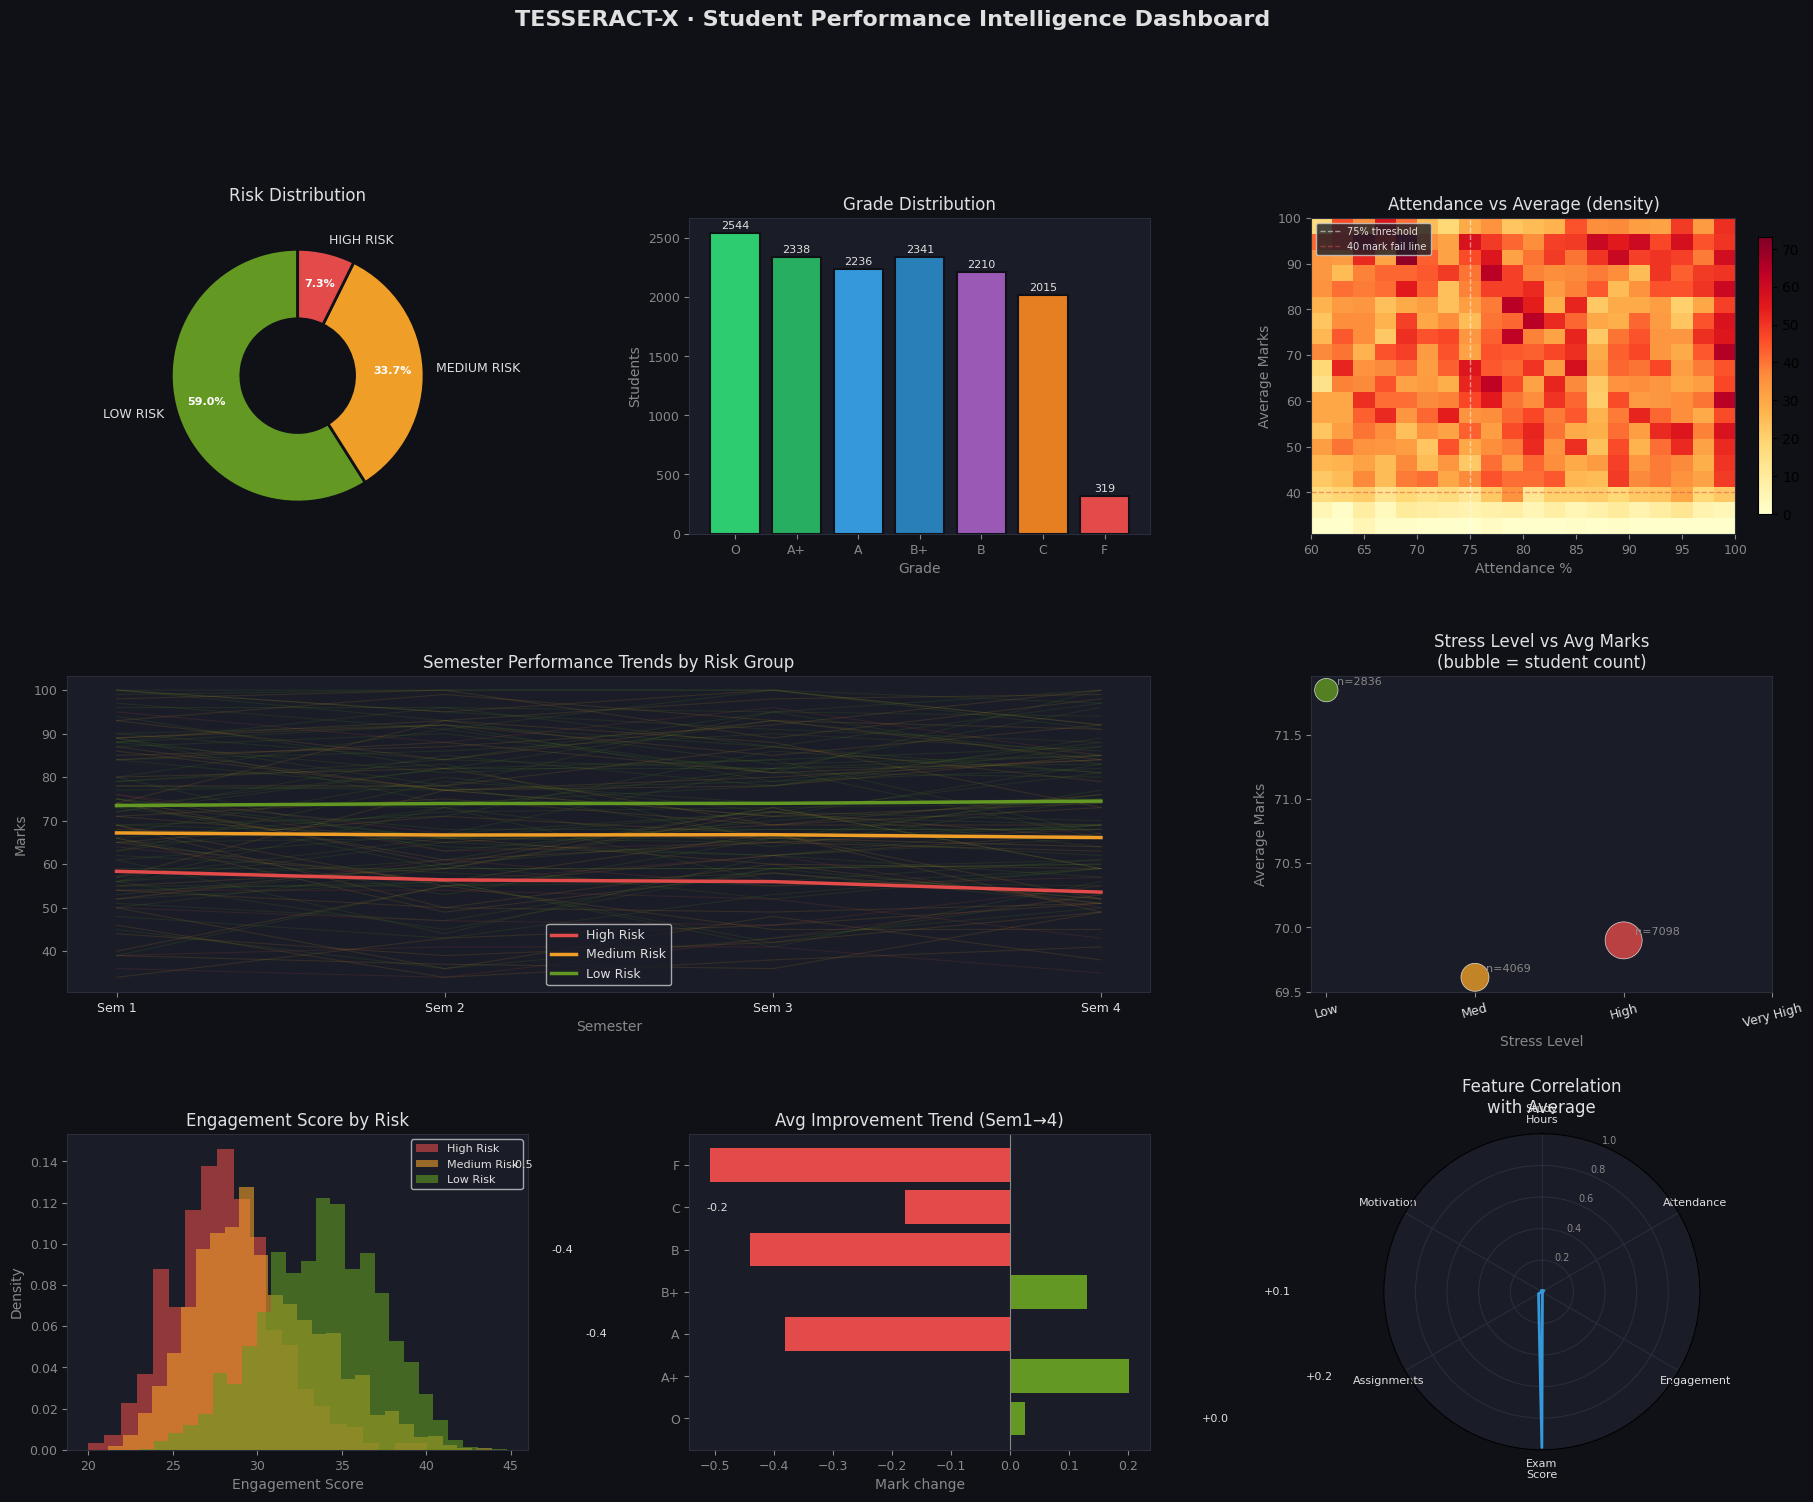

✅ Teacher dashboard saved: teacher_dashboard.png


In [ ]:
# ============================================================
# STEP 14: CREATIVE VISUALIZATIONS FOR TEACHER DASHBOARD
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

COLOR_HIGH   = '#E24B4A'
COLOR_MED    = '#EF9F27'
COLOR_LOW    = '#639922'
COLOR_BG     = '#0f1117'
COLOR_CARD   = '#1a1d27'
COLOR_TEXT   = '#e0e0e0'
COLOR_MUTED  = '#888'

def dark_ax(ax):
    ax.set_facecolor(COLOR_CARD)
    ax.tick_params(colors=COLOR_MUTED, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2d3a')
    ax.title.set_color(COLOR_TEXT)
    ax.xaxis.label.set_color(COLOR_MUTED)
    ax.yaxis.label.set_color(COLOR_MUTED)

# ── 14A. Risk Donut ──
ax1 = fig.add_subplot(gs[0, 0])
dark_ax(ax1)
risk_counts = df_orig['Risk_Level'].value_counts()
risk_labels_clean = [r.split(' ', 1)[1] for r in risk_counts.index]
colors_donut = [COLOR_HIGH if 'HIGH' in r else COLOR_MED if 'MEDIUM' in r else COLOR_LOW
                for r in risk_counts.index]
wedges, texts, autotexts = ax1.pie(
    risk_counts.values, labels=risk_labels_clean,
    colors=colors_donut, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=COLOR_BG, linewidth=2)
)
for t in texts: t.set_color(COLOR_TEXT); t.set_fontsize(9)
for at in autotexts: at.set_color('#fff'); at.set_fontsize(8); at.set_fontweight('bold')
ax1.set_title('Risk Distribution', pad=12)

# ── 14B. Grade Waterfall ──
ax2 = fig.add_subplot(gs[0, 1])
dark_ax(ax2)
grade_order = ['O','A+','A','B+','B','C','F']
grade_counts = df_orig['Grade'].value_counts().reindex(grade_order, fill_value=0)
bar_colors = ['#2ecc71','#27ae60','#3498db','#2980b9','#9b59b6','#e67e22', COLOR_HIGH]
bars = ax2.bar(grade_order, grade_counts.values, color=bar_colors, edgecolor=COLOR_BG, linewidth=1.5)
for bar, val in zip(bars, grade_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', color=COLOR_TEXT, fontsize=8)
ax2.set_title('Grade Distribution')
ax2.set_xlabel('Grade')
ax2.set_ylabel('Students')

# ── 14C. Attendance vs Average Heatmap ──
ax3 = fig.add_subplot(gs[0, 2])
dark_ax(ax3)
h, xedges, yedges = np.histogram2d(
    df_orig['Attendance'].clip(0,100),
    df_orig['Average'].clip(0,100),
    bins=20
)
im = ax3.imshow(h.T, origin='lower', aspect='auto', cmap='YlOrRd',
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
ax3.set_title('Attendance vs Average (density)')
ax3.set_xlabel('Attendance %')
ax3.set_ylabel('Average Marks')
plt.colorbar(im, ax=ax3, fraction=0.03)
ax3.axvline(75, color='#fff', linestyle='--', alpha=0.5, linewidth=1, label='75% threshold')
ax3.axhline(40, color=COLOR_HIGH, linestyle='--', alpha=0.5, linewidth=1, label='40 mark fail line')
ax3.legend(fontsize=7, facecolor=COLOR_CARD, labelcolor=COLOR_TEXT, loc='upper left')

# ── 14D. Semester trend lines (sample 100 students) ──
ax4 = fig.add_subplot(gs[1, :2])
dark_ax(ax4)
sem_cols = ['Sem1_Marks','Sem2_Marks','Sem3_Marks','Sem4_Marks']
sample = df_orig.sample(min(100, len(df_orig)), random_state=42)
for _, row in sample.iterrows():
    risk = row['Risk_Level']
    color = COLOR_HIGH if 'HIGH' in risk else COLOR_MED if 'MEDIUM' in risk else COLOR_LOW
    ax4.plot([1,2,3,4], row[sem_cols].values, color=color, alpha=0.12, linewidth=0.8)
# Mean lines per risk group
for risk_label, color, label in [('🔴 HIGH RISK', COLOR_HIGH, 'High Risk'),
                                   ('🟡 MEDIUM RISK', COLOR_MED, 'Medium Risk'),
                                   ('🟢 LOW RISK', COLOR_LOW, 'Low Risk')]:
    subset = df_orig[df_orig['Risk_Level'] == risk_label]
    if len(subset):
        means = subset[sem_cols].mean().values
        ax4.plot([1,2,3,4], means, color=color, linewidth=2.5, label=label, zorder=5)
ax4.set_title('Semester Performance Trends by Risk Group')
ax4.set_xlabel('Semester')
ax4.set_ylabel('Marks')
ax4.set_xticks([1,2,3,4])
ax4.set_xticklabels(['Sem 1','Sem 2','Sem 3','Sem 4'], color=COLOR_TEXT)
ax4.legend(facecolor=COLOR_CARD, labelcolor=COLOR_TEXT, fontsize=9)

# ── 14E. Stress vs Performance Bubble ──
ax5 = fig.add_subplot(gs[1, 2])
dark_ax(ax5)
stress_groups = df_orig.groupby('StressLevel')['Average'].mean()
counts        = df_orig.groupby('StressLevel').size()
bubble_colors = [COLOR_LOW, COLOR_MED, COLOR_HIGH, '#8B0000']
ax5.scatter(stress_groups.index, stress_groups.values,
            s=counts.values/10, c=bubble_colors[:len(stress_groups)],
            alpha=0.8, edgecolors='white', linewidth=0.5)
for i, (sl, avg) in enumerate(stress_groups.items()):
    ax5.annotate(f'n={counts[sl]}', (sl, avg), textcoords='offset points',
                 xytext=(8, 4), color=COLOR_MUTED, fontsize=8)
ax5.set_title('Stress Level vs Avg Marks\n(bubble = student count)')
ax5.set_xlabel('Stress Level')
ax5.set_ylabel('Average Marks')
ax5.set_xticks([0,1,2,3])
ax5.set_xticklabels(['Low','Med','High','Very High'], rotation=15, color=COLOR_TEXT)

# Add Engagement_Score to df_orig for visualization
df_orig['Engagement_Score'] = (
    df_orig['StudyHours'] * 0.3 +
    df_orig['Attendance'] * 0.3 +
    df_orig['OnlineCourses'] * 0.2 +
    df_orig['Discussions'] * 0.2
)

# ── 14F. Engagement Score Distribution ──
ax6 = fig.add_subplot(gs[2, 0])
dark_ax(ax6)
for risk_label, color, label in [('🔴 HIGH RISK', COLOR_HIGH, 'High Risk'),
                                   ('🟡 MEDIUM RISK', COLOR_MED, 'Medium Risk'),
                                   ('🟢 LOW RISK', COLOR_LOW, 'Low Risk')]:
    subset = df_orig[df_orig['Risk_Level'] == risk_label]['Engagement_Score']
    ax6.hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
ax6.set_title('Engagement Score by Risk')
ax6.set_xlabel('Engagement Score')
ax6.set_ylabel('Density')
ax6.legend(facecolor=COLOR_CARD, labelcolor=COLOR_TEXT, fontsize=8)

# ── 14G. Improvement trend heatmap by grade ──
ax7 = fig.add_subplot(gs[2, 1])
dark_ax(ax7)
df_orig['Improvement_Trend'] = df_orig['Sem4_Marks'] - df_orig['Sem1_Marks']
pivot = df_orig.groupby('Grade')['Improvement_Trend'].mean().reindex(grade_order)
bars2 = ax7.barh(grade_order, pivot.values,
                  color=[COLOR_LOW if v > 0 else COLOR_HIGH for v in pivot.values])
ax7.axvline(0, color=COLOR_MUTED, linewidth=0.8)
ax7.set_title('Avg Improvement Trend (Sem1→4)')
ax7.set_xlabel('Mark change')
for bar, val in zip(bars2, pivot.values):
    ax7.text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
             f'{val:+.1f}', va='center', ha='left' if val >= 0 else 'right',
             color=COLOR_TEXT, fontsize=8)

# ── 14H. Feature correlation radar (top 6 features) ──
ax8 = fig.add_subplot(gs[2, 2], polar=True)
ax8.set_facecolor(COLOR_CARD)
ax8.tick_params(colors=COLOR_MUTED)
top_feats = ['StudyHours','Attendance','Engagement_Score','ExamScore','AssignmentCompletion','Motivation']
corr_vals = [abs(df_orig[f].corr(df_orig['Average'])) for f in top_feats]
labels = ['Study\nHours','Attendance','Engagement','Exam\nScore','Assignments','Motivation']
N = len(labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
corr_vals_plot = corr_vals + corr_vals[:1]
ax8.set_theta_offset(np.pi / 2)
ax8.set_theta_direction(-1)
ax8.set_xticks(angles[:-1])
ax8.set_xticklabels(labels, color=COLOR_TEXT, fontsize=8)
ax8.set_ylim(0, 1)
ax8.plot(angles, corr_vals_plot, color='#3498db', linewidth=2)
ax8.fill(angles, corr_vals_plot, color='#3498db', alpha=0.2)
ax8.set_title('Feature Correlation\nwith Average', color=COLOR_TEXT, pad=15)
ax8.yaxis.set_tick_params(labelcolor=COLOR_MUTED, labelsize=7)
ax8.grid(color='#2a2d3a')

plt.suptitle('TESSERACT-X · Student Performance Intelligence Dashboard',
             fontsize=16, fontweight='bold', color=COLOR_TEXT, y=1.01)
plt.savefig('teacher_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=COLOR_BG, edgecolor='none')
plt.show()
print("✅ Teacher dashboard saved: teacher_dashboard.png")

In [ ]:
# ============================================================
# STEP 15: CLASS-LEVEL ALERT REPORT FOR TEACHERS
# ============================================================

print("=" * 60)
print("STEP 15: TEACHER ALERT REPORT")
print("=" * 60)

# ── 15A. Top 20 students who need intervention ──
df_alert = df_orig[df_orig['Risk_Level'].str.contains('HIGH')].copy()
df_alert = df_alert.sort_values('Average').head(20)

alert_cols = ['RollNo','Average','Attendance','StudyHours','StressLevel',
              'Improvement_Trend','Risk_Level','Grade','Pass_Fail']
alert_cols = [c for c in alert_cols if c in df_alert.columns]

print(f"\n🔴 TOP 20 HIGH-RISK STUDENTS NEEDING IMMEDIATE ATTENTION:")
print(df_alert[alert_cols].to_string(index=False))

# ── 15B. Generate per-student recommendation PDF-ready text ──
def format_student_report(row):
    risk, factors, score = classify_risk(row.to_dict())
    recs = generate_recommendations(row.to_dict())
    report = f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STUDENT: {row.get('RollNo','N/A')}  |  GRADE: {row.get('Grade','N/A')}  |  AVG: {row.get('Average',0):.1f}
RISK: {risk}  (Score: {score}/12)
PASS/FAIL: {row.get('Pass_Fail','N/A')}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Risk Factors:
{'  • ' + chr(10) + '  • '.join(factors) if factors else '  None identified'}

Recommendations:
{'  ' + chr(10) + '  '.join(recs)}
"""
    return report

# Print reports for top 5 high-risk students
print("\n\n📋 DETAILED STUDENT REPORTS:")
for _, row in df_alert.head(5).iterrows():
    print(format_student_report(row))

# ── 15C. Class summary statistics ──
print("\n── CLASS SUMMARY STATISTICS ──")
summary = {
    'Total Students': len(df_orig),
    'Pass Count': (df_orig['Pass_Fail'] == 'Pass').sum() if df_orig['Pass_Fail'].dtype == object else (df_orig['Pass_Fail'] == 1).sum(),
    'Fail Count': (df_orig['Pass_Fail'] == 'Fail').sum() if df_orig['Pass_Fail'].dtype == object else (df_orig['Pass_Fail'] == 0).sum(),
    'High Risk': df_orig['Risk_Level'].str.contains('HIGH').sum(),
    'Medium Risk': df_orig['Risk_Level'].str.contains('MEDIUM').sum(),
    'Low Risk': df_orig['Risk_Level'].str.contains('LOW').sum(),
    'Avg Study Hours': df_orig['StudyHours'].mean(),
    'Avg Attendance %': df_orig['Attendance'].mean(),
    'Avg Score': df_orig['Average'].mean(),
}
for k, v in summary.items():
    val = f"{v:.1f}" if isinstance(v, float) else str(v)
    print(f"  {k:<22} : {val}")

# ── 15D. Save alert report ──
df_alert.to_csv('high_risk_alert_report.csv', index=False)
print("\n✅ Alert report saved: high_risk_alert_report.csv")

STEP 15: TEACHER ALERT REPORT

🔴 TOP 20 HIGH-RISK STUDENTS NEEDING IMMEDIATE ATTENTION:
  RollNo  Average  Attendance  StudyHours  StressLevel  Improvement_Trend  Risk_Level Grade Pass_Fail
 STU3145    31.00          64          10            2                 -1 🔴 HIGH RISK     F      Fail
STU14390    32.25          68          13            0                 -7 🔴 HIGH RISK     F      Fail
 STU9174    33.00          66          18            0                 -1 🔴 HIGH RISK     F      Fail
 STU9864    33.50          65          23            1                  3 🔴 HIGH RISK     F      Fail
 STU3562    33.50          65          24            1                  0 🔴 HIGH RISK     F      Fail
 STU1015    33.75          64          19            1                  6 🔴 HIGH RISK     F      Fail
 STU2714    33.75          76          24            2                  0 🔴 HIGH RISK     F      Fail
 STU7571    34.00          64          27            1                  8 🔴 HIGH RISK     F     


STEP 17: FINAL PROJECT SUMMARY
❌ ERROR: name 'dt_acc' is not defined
👉 Please run the main pipeline cell (P8HChvhX4KKT) before running this summary cell.


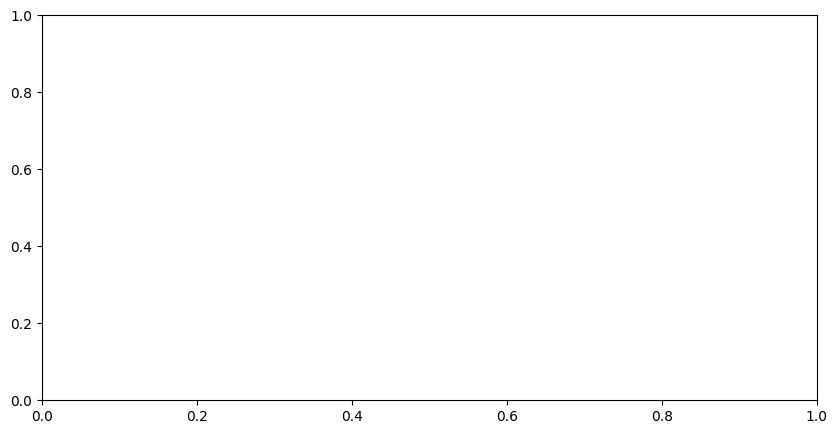

In [ ]:
# ============================================================
# STEP 17: FINAL SUMMARY CARD + JUDGE-READY OUTPUT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# IMPORTANT: Ensure cell P8HChvhX4KKT has been executed successfully
# to define: acc_bin, f1_bin, acc_grade, f1_grade, rf_acc, rf_f1, dt_acc, dt_f1, and df_orig.

print("\n" + "=" * 60)
print("STEP 17: FINAL PROJECT SUMMARY")
print("=" * 60)

try:
    # ── 17A. Benchmark comparison chart ──
    fig, ax = plt.subplots(figsize=(10, 5))
    models   = ['Decision\nTree', 'Random\nForest', 'PyTorch NN\n(Grade)', 'PyTorch NN\n(Pass/Fail)']
    accs     = [dt_acc * 100, rf_acc * 100, acc_grade * 100, acc_bin * 100]
    f1s      = [dt_f1  * 100, rf_f1  * 100, f1_grade  * 100, f1_bin  * 100]

    x = np.arange(len(models))
    w = 0.35
    bars1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='#3498db', edgecolor='white', linewidth=1.2)
    bars2 = ax.bar(x + w/2, f1s,  w, label='F1 Score',  color='#2ecc71', edgecolor='white', linewidth=1.2)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title('Model Comparison — Accuracy & F1 Score', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, 110)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── 17B. Final summary print ──
    print(f"""
    ╔══════════════════════════════════════════════════════════╗
    ║         TESSERACT-X · FINAL PROJECT SUMMARY             ║
    ╠══════════════════════════════════════════════════════════╣
    ║  Dataset       : {len(df_orig):,} students × 25 features              ║
    ║  PyTorch NN    : Pass/Fail Acc = {acc_bin:.3f} | F1 = {f1_bin:.3f}      ║
    ║  PyTorch NN    : Grade Acc    = {acc_grade:.3f} | F1 = {f1_grade:.3f}      ║
    ║  Random Forest : Acc = {rf_acc:.3f} | F1 = {rf_f1:.3f}                ║
    ║  Decision Tree : Acc = {dt_acc:.3f} | F1 = {dt_f1:.3f}                ║
    ╠══════════════════════════════════════════════════════════╣
    ║  Risk Segments :                                         ║
    ║    High Risk   : {df_orig['Risk_Level'].str.contains('HIGH').sum():,} students                         ║
    ║    Medium Risk : {df_orig['Risk_Level'].str.contains('MEDIUM').sum():,} students                        ║
    ║    Low Risk    : {df_orig['Risk_Level'].str.contains('LOW').sum():,} students                         ║
    ╚══════════════════════════════════════════════════════════╝
    """)
except NameError as e:
    print(f"❌ ERROR: {e}")
    print("👉 Please run the main pipeline cell (P8HChvhX4KKT) before running this summary cell.")

In [ ]:
# Replace the shutil.make_archive line with this:
import zipfile, os

output_files = [
    'model_pass_fail.pth', 'model_grade.pth',
    'scaler.pkl', 'encoders.pkl', 'feature_cols.pkl',
    'teacher_dashboard.png', 'model_comparison.png',
    'high_risk_alert_report.csv', 'student_risk_report.csv',
    'eda_overview.png', 'training_curves.png', 'feature_importance.png'
]

with zipfile.ZipFile('tesseract_x_output.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"  ✅ Added: {f}")

from google.colab import files
files.download('tesseract_x_output.zip')
print("✅ Download started!")

  ✅ Added: model_pass_fail.pth
  ✅ Added: model_grade.pth
  ✅ Added: scaler.pkl
  ✅ Added: encoders.pkl
  ✅ Added: feature_cols.pkl
  ✅ Added: teacher_dashboard.png
  ✅ Added: model_comparison.png
  ✅ Added: high_risk_alert_report.csv
  ✅ Added: student_risk_report.csv
  ✅ Added: eda_overview.png
  ✅ Added: training_curves.png
  ✅ Added: feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


In [ ]:
# ============================================================
# STEP 18: EXPORT predict_student() AS A STANDALONE MODULE
# This is what your backend teammate copies into FastAPI
# ============================================================

api_code = '''
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle

# ── Load artifacts (run once at startup) ──
with open("scaler.pkl", "rb") as f:      scaler = pickle.load(f)
with open("encoders.pkl", "rb") as f:    le_dict = pickle.load(f)
with open("feature_cols.pkl", "rb") as f: feature_cols = pickle.load(f)

class StudentNet(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x): return self.network(x)

input_dim = len(feature_cols)
model_bin   = StudentNet(input_dim, 2);   model_bin.load_state_dict(torch.load("model_pass_fail.pth", map_location="cpu")); model_bin.eval()
model_grade = StudentNet(input_dim, len(le_dict["Grade"].classes_)); model_grade.load_state_dict(torch.load("model_grade.pth", map_location="cpu")); model_grade.eval()

def predict_student(data: dict) -> dict:
    row = pd.DataFrame([data])
    sem = ["Sem1_Marks","Sem2_Marks","Sem3_Marks","Sem4_Marks"]
    row["Mark_Consistency"]  = row[sem].std(axis=1) if all(s in row for s in sem) else 0
    row["Improvement_Trend"] = row["Sem4_Marks"] - row["Sem1_Marks"] if all(s in row for s in sem) else 0
    row["Engagement_Score"]  = (row.get("StudyHours",0)*0.3 + row.get("Attendance",0)*0.3 +
                                row.get("OnlineCourses",0)*0.2 + row.get("Discussions",0)*0.2)
    if "Gender" in row and "Gender" in le_dict:
        try: row["Gender"] = le_dict["Gender"].transform(row["Gender"])
        except: row["Gender"] = 0
    X = scaler.transform(row[feature_cols].fillna(0).values)
    t = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        pf_prob    = torch.softmax(model_bin(t),   dim=1)[0].numpy()
        grade_prob = torch.softmax(model_grade(t), dim=1)[0].numpy()
    return {
        "pass_fail":   "Pass" if np.argmax(pf_prob) == 1 else "Fail",
        "pass_prob":   round(float(pf_prob[1]), 4),
        "grade":       le_dict["Grade"].inverse_transform([np.argmax(grade_prob)])[0],
        "grade_probs": {le_dict["Grade"].inverse_transform([i])[0]: round(float(p),4) for i,p in enumerate(grade_prob)},
    }
'''

with open("ml_module.py", "w") as f:
    f.write(api_code)

print("✅ ml_module.py saved — give this file to your backend teammate")

✅ ml_module.py saved — give this file to your backend teammate
